# SOO

In [5]:
from zellij.utils.benchmarks import Rosenbrock
from zellij.core import (
    ArrayVar,
    FloatVar,
    Loss,
    Experiment,
    Threshold,
    Minimizer,
)
from zellij.strategies.fractals import DBASampling, CenterSOO
from zellij.strategies.tools import Section, Min, SooTreeSearch
from zellij.utils.converters import FloatMinMax, ArrayDefaultC


dim = 2
calls = dim * 10**3

fun = Rosenbrock()

lf = Loss(
    objective=[Minimizer("obj")],
    only_score=False,
)(fun)

values = ArrayVar(converter=ArrayDefaultC())
for i in range(dim):
    values.append(
        FloatVar(f"float_{i+1}", fun.lower, fun.upper, converter=FloatMinMax())
    )

sp = Section(values, section=3)

explor = CenterSOO(sp)

stop2 = Threshold(lf, "calls", calls)
dba = DBASampling(sp, SooTreeSearch(sp, float("inf")), explor, scoring=Min())
exp = Experiment(dba, lf, stop2, save="testsoo")
exp.run()
print(f"Best solution:f({lf.best_point})={lf.best_score}>={fun.optimum*dim}")

ENDING: |T|calls:2000>=2000
Best solution:f([[0.9999999997132072, 0.9999999997132072]])=[8.3072618e-18]>=0


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def print_res(path):
    data = pd.read_csv(path, encoding="latin-1")
    argmin = data["obj"].argmin()
    print(f"MIN : {data['obj'].min()}")
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect("equal", adjustable="box")

    x = y = np.linspace(fun.lower - 3, fun.upper, 100)
    X, Y = np.meshgrid(x, y)
    Z = (1-X)**2+100*(Y-X**2)**2  # Rosenbrock

    map = ax.contourf(X, Y, Z, cmap="plasma", levels=100)
    fig.colorbar(map, fraction=0.046, pad=0.04)

    xc = data["float_1"]
    yc = data["float_2"]
    xb = data["float_1"].iloc[argmin]
    yb = data["float_2"].iloc[argmin]

    plt.scatter(xc, yc, c="cyan", s=3)
    plt.scatter(xb, yb, c="green")
    plt.scatter(fun.poptimum, fun.poptimum, c="red", alpha=0.5)

    plt.plot()

MIN : 8.307261802348406e-18


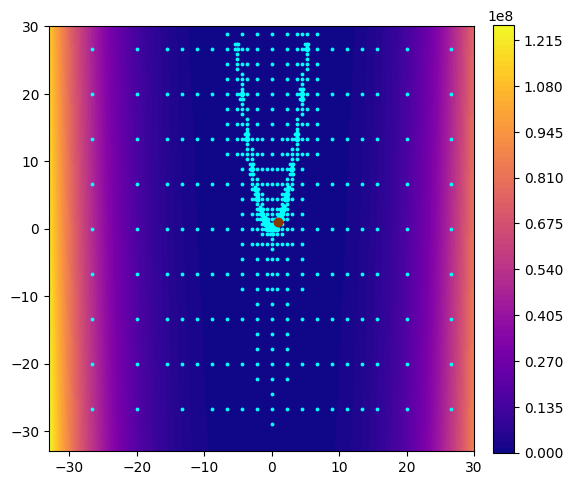

In [7]:
print_res("./testsoo/outputs/all_evaluations.csv")